In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = "../data"
FIG_DIR  = "../paper/images"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(filename, dpi=300):
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"Saved → {path}")

In [2]:
df = pd.read_csv(f"{DATA_DIR}/data_clean.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f"Shape  : {df.shape}")
print(f"Leaks  : {df['Leak Status'].sum()}")
df.head()


Shape  : (990, 6)
Leaks  : 19


,Timestamp,Sensor_ID,Pressure (bar),Flow Rate (L/s),Temperature (°C),Leak Status
0,2024-01-01 01:10:00,S001,2.595338,96.647348,14.877750,0
1,2024-01-01 02:20:00,S001,2.726076,126.229817,20.437192,0
2,2024-01-01 02:30:00,S001,3.096358,127.662703,22.565652,0
3,2024-01-01 05:15:00,S001,3.477227,81.002654,14.109417,0
4,2024-01-01 05:45:00,S001,3.257879,173.968620,14.800744,0


In [3]:
# Rate of pressure change between consecutive readings of the SAME sensor
df = df.sort_values(['Sensor_ID', 'Timestamp']).reset_index(drop=True)
df['pressure_delta'] = df.groupby('Sensor_ID')['Pressure (bar)'].diff().fillna(0)

print("pressure_delta stats by class:")
print(df.groupby('Leak Status')['pressure_delta'].describe().round(4))


pressure_delta stats by class:
             count    mean     std     min     25%     50%     75%     max
Leak Status                                                               
0            971.0  0.0217  0.6109 -1.4000 -0.3951  0.0092  0.4361  2.0301
1             19.0 -0.9526  0.8236 -2.2531 -1.4661 -0.9691 -0.6523  1.3604


In [4]:
# How abnormal is this flow reading relative to THIS sensor's own baseline
def compute_zscore(group):
    mu    = group['Flow Rate (L/s)'].mean()
    sigma = group['Flow Rate (L/s)'].std() + 1e-8
    group['flow_zscore'] = (group['Flow Rate (L/s)'] - mu) / sigma
    return group

df = df.groupby('Sensor_ID', group_keys=False).apply(compute_zscore)

print("flow_zscore stats by class:")
print(df.groupby('Leak Status')['flow_zscore'].describe().round(4))


flow_zscore stats by class:
             count    mean     std     min     25%     50%     75%     max
Leak Status                                                               
0            971.0 -0.0100  0.9865 -1.8414 -0.8451 -0.0228  0.8246  2.0287
1             19.0  0.5123  1.3127 -1.3595 -0.7893  0.4282  1.7768  2.4173


/tmp/ipykernel_127438/1122159512.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Sensor_ID', group_keys=False).apply(compute_zscore)


In [5]:
# Drops sharply during leaks: pressure falls + flow rises simultaneously
df['pf_ratio'] = df['Pressure (bar)'] / (df['Flow Rate (L/s)'] + 1e-8)

print("pf_ratio stats by class:")
print(df.groupby('Leak Status')['pf_ratio'].describe().round(6))


pf_ratio stats by class:
             count      mean       std       min       25%       50%  \
Leak Status                                                            
0            971.0  0.030300  0.013104  0.013104  0.020375  0.026143   
1             19.0  0.018217  0.010638  0.006995  0.010399  0.015181   

                  75%       max  
Leak Status                      
0            0.037126  0.074004  
1            0.024102  0.039302  


In [6]:
sensor_map = {s: i for i, s in enumerate(sorted(df['Sensor_ID'].unique()))}
df['sensor_enc'] = df['Sensor_ID'].map(sensor_map)

print("Sensor mapping:")
print(sensor_map)


Sensor mapping:
{'S001': 0, 'S002': 1, 'S003': 2, 'S004': 3, 'S005': 4, 'S006': 5, 'S007': 6, 'S008': 7, 'S009': 8, 'S010': 9}


In [7]:
# Confirmed in EDA: correlation with Leak Status < 0.02 — pure noise
df = df.drop(columns=['Temperature (°C)'])

print("Remaining columns:")
print(df.columns.tolist())


Remaining columns:
['Timestamp', 'Sensor_ID', 'Pressure (bar)', 'Flow Rate (L/s)', 'Leak Status', 'pressure_delta', 'flow_zscore', 'pf_ratio', 'sensor_enc']


In [8]:
FEATURES = ['Pressure (bar)', 'Flow Rate (L/s)',
            'pressure_delta', 'flow_zscore',
            'pf_ratio', 'sensor_enc']

print(f"Feature count : {len(FEATURES)}")
print(f"Features      : {FEATURES}")
print(f"\nDataset shape : {df[FEATURES].shape}")
print(f"\nFull stats:")
print(df[FEATURES].describe().round(4))


Feature count : 6
Features      : ['Pressure (bar)', 'Flow Rate (L/s)', 'pressure_delta', 'flow_zscore', 'pf_ratio', 'sensor_enc']

Dataset shape : (990, 6)

Full stats:
       Pressure (bar)  Flow Rate (L/s)  pressure_delta  flow_zscore  pf_ratio  \
count        990.0000         990.0000        990.0000     990.0000  990.0000   
mean           3.2396         124.6243          0.0030       0.0000    0.0301   
std            0.4517          43.5374          0.6295       0.9954    0.0132   
min            1.5285          50.6545         -2.2531      -1.8414    0.0070   
25%            2.8712          87.9327         -0.4227      -0.8464    0.0202   
50%            3.2717         123.5108          0.0000      -0.0163    0.0260   
75%            3.6090         161.9198          0.4296       0.8432    0.0370   
max            3.9954         228.4944          2.0301       2.4173    0.0740   

       sensor_enc  
count    990.0000  
mean       4.5990  
std        2.8805  
min        0.0000  


Saved → ../paper/images/fig5_feature_distributions.png


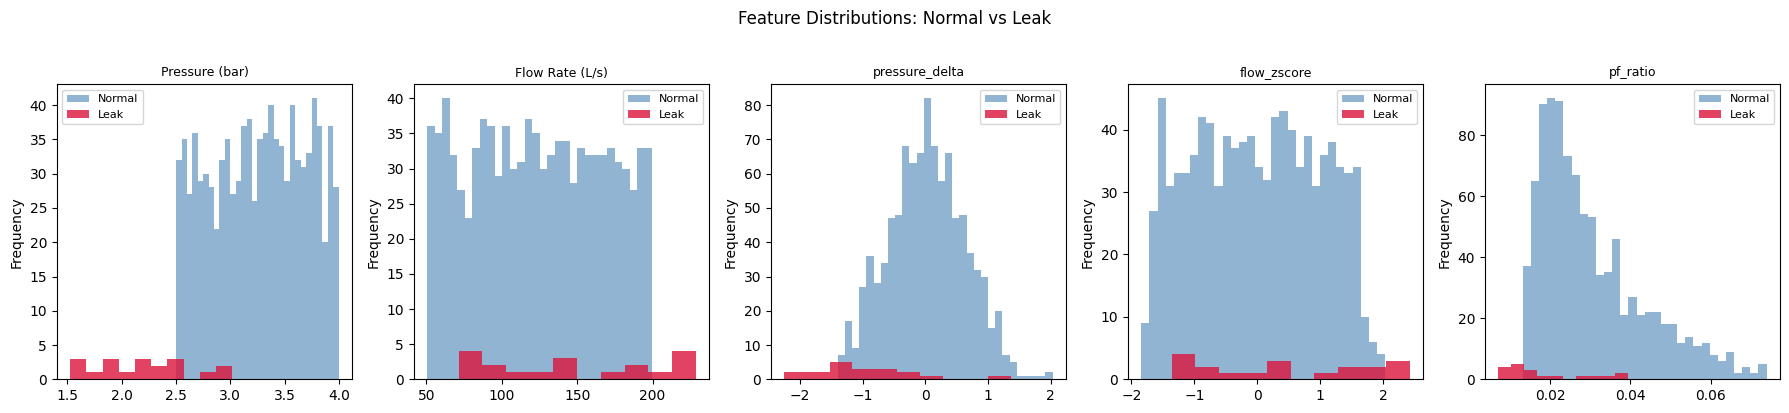

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

raw_feats = ['Pressure (bar)', 'Flow Rate (L/s)',
             'pressure_delta', 'flow_zscore', 'pf_ratio']

for ax, feat in zip(axes, raw_feats):
    df[df['Leak Status']==0][feat].plot.hist(
        bins=30, alpha=0.6, label='Normal', ax=ax, color='steelblue')
    df[df['Leak Status']==1][feat].plot.hist(
        bins=10, alpha=0.8, label='Leak', ax=ax, color='crimson')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions: Normal vs Leak", fontsize=12, y=1.02)
plt.tight_layout()
save_fig("fig5_feature_distributions.png")
plt.show()


In [10]:
df.to_csv(f"{DATA_DIR}/data_engineered.csv", index=False)

print(f"Saved → {DATA_DIR}/data_engineered.csv")
print(f"Shape  : {df.shape}")
print(f"Leaks  : {df['Leak Status'].sum()}")
print(f"Features saved: {FEATURES}")


Saved → ../data/data_engineered.csv
Shape  : (990, 9)
Leaks  : 19
Features saved: ['Pressure (bar)', 'Flow Rate (L/s)', 'pressure_delta', 'flow_zscore', 'pf_ratio', 'sensor_enc']
